<a href="https://colab.research.google.com/github/Prad0510/Learning-MachineVision/blob/main/MVision6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pradnya Dhengale    23102C0007

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

Saving image.jpeg to image.jpeg


(np.float64(-0.5), np.float64(1049.5), np.float64(699.5), np.float64(-0.5))

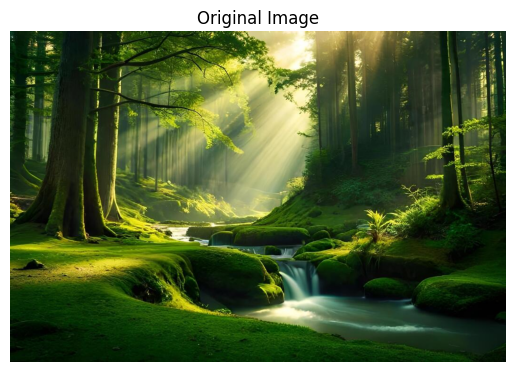

In [3]:
image = cv2.imread(list(uploaded.keys())[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

(np.float64(-0.5), np.float64(1049.5), np.float64(699.5), np.float64(-0.5))

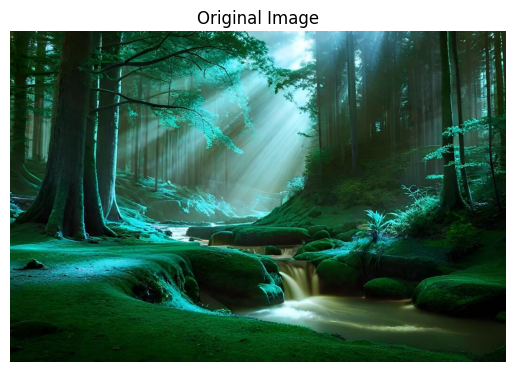

In [4]:
imag = cv2.imread(list(uploaded.keys())[0])

plt.imshow(imag)
plt.title("Original Image")
plt.axis("off")

(np.float64(-0.5), np.float64(1049.5), np.float64(699.5), np.float64(-0.5))

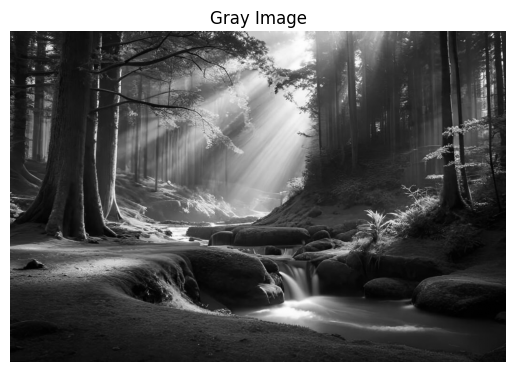

In [5]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Gray Image")
plt.axis("off")

**Global Thresholding**

In [6]:
_, global_thresh = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

(np.float64(-0.5), np.float64(1049.5), np.float64(699.5), np.float64(-0.5))

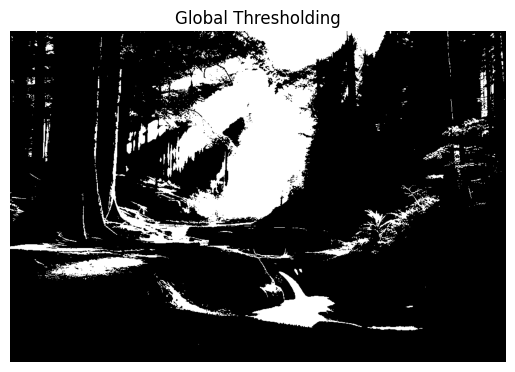

In [7]:
plt.imshow(global_thresh, cmap='gray')
plt.title("Global Thresholding")
plt.axis("off")

It works well only when lighting is uniform.

**Adaptive Thresholding**

(np.float64(-0.5), np.float64(1049.5), np.float64(699.5), np.float64(-0.5))

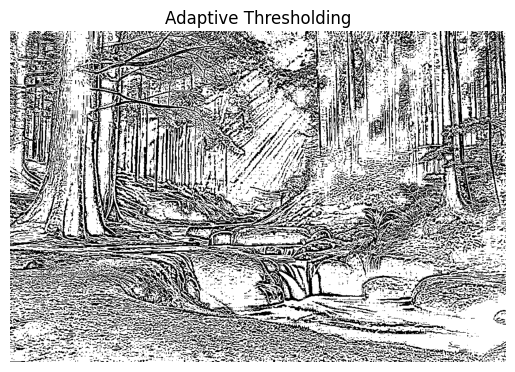

In [8]:
adaptive_thresh = cv2.adaptiveThreshold(gray,
                                        255,
                                        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY,
                                        11,
                                        2
                                        )
plt.imshow(adaptive_thresh, cmap='gray')
plt.title("Adaptive Thresholding")
plt.axis("off")

Adaptive threshold uses different thresholds for different regions.

**Edge-Based Segmentation (Canny Edge Detection)**

(np.float64(-0.5), np.float64(1049.5), np.float64(699.5), np.float64(-0.5))

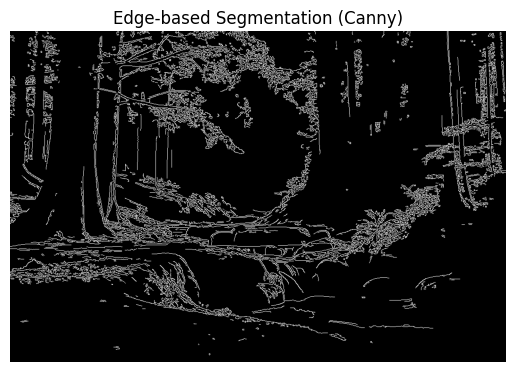

In [12]:
edges = cv2.Canny(gray,100,200)
plt.imshow(edges, cmap='gray')
plt.title("Edge-based Segmentation (Canny)")
plt.axis("off")

**Region-Based Segmentation**

/tmp/ipykernel_598/966466068.py:22: RuntimeWarning: overflow encountered in scalar subtract
  if abs(img[nx,ny] - seed_value) < threshold:


(np.float64(-0.5), np.float64(1049.5), np.float64(699.5), np.float64(-0.5))

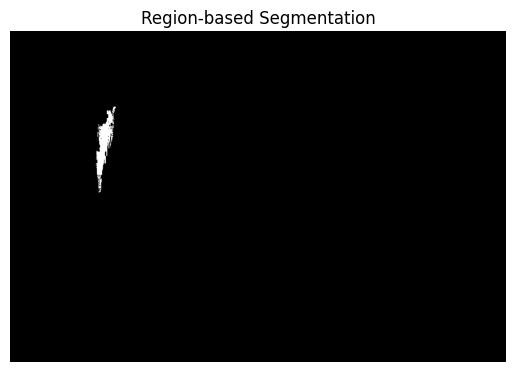

In [29]:
def region_growing(img,seed):
  h,w = img.shape
  segmented = np.zeros((h,w),np.uint8)

  seed_value = img[seed]
  threshold = 10

  stack = [seed]

  while stack:
    x,y = stack.pop()

    if segmented[x,y] == 0:
      segmented[x,y] = 255

      for dx in [-1,0,1]:
        for dy in [-1,0,1]:
          nx = x + dx
          ny = y + dy

          if 0<= nx < h and 0 <= ny < w:
            if abs(img[nx,ny] - seed_value) < threshold:
              stack.append((nx,ny))
  return segmented

seed_point = (200,200)
segmented_image = region_growing(gray,seed_point)

plt.imshow(segmented_image, cmap='gray')
plt.title("Region-based Segmentation")
plt.axis("off")



/tmp/ipykernel_598/966466068.py:22: RuntimeWarning: overflow encountered in scalar subtract
  if abs(img[nx,ny] - seed_value) < threshold:


(np.float64(-0.5), np.float64(1049.5), np.float64(699.5), np.float64(-0.5))

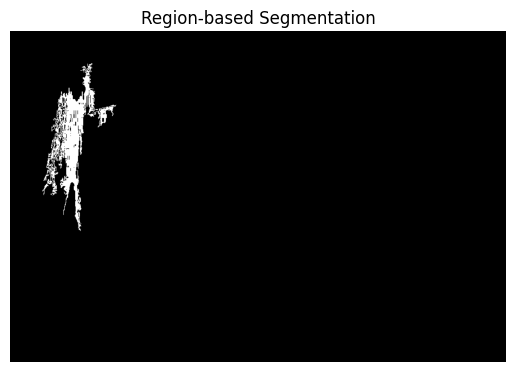

In [30]:
seed_point = (150,150)
segmented_image = region_growing(gray,seed_point)

plt.imshow(segmented_image, cmap='gray')
plt.title("Region-based Segmentation")
plt.axis("off")

/tmp/ipykernel_598/966466068.py:22: RuntimeWarning: overflow encountered in scalar subtract
  if abs(img[nx,ny] - seed_value) < threshold:


(np.float64(-0.5), np.float64(1049.5), np.float64(699.5), np.float64(-0.5))

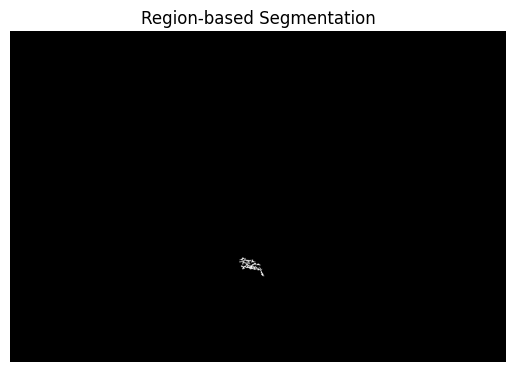

In [33]:
seed_point = (500,500)
segmented_image = region_growing(gray,seed_point)

plt.imshow(segmented_image, cmap='gray')
plt.title("Region-based Segmentation")
plt.axis("off")

In [26]:
gray.shape

(700, 1050)

**Clustering-Based Segmentation (K-Means)**

(np.float64(-0.5), np.float64(1049.5), np.float64(699.5), np.float64(-0.5))

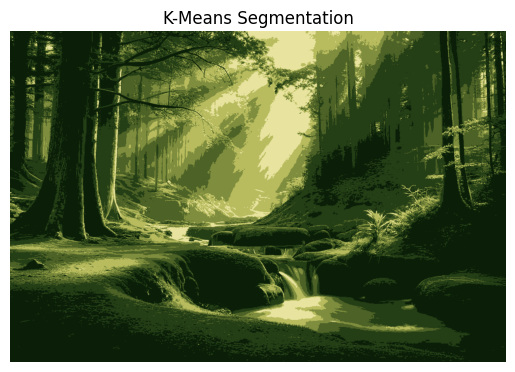

In [35]:
pixel_values = image.reshape((-1,3))
pixel_values = np.float32(pixel_values)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

k = 6

_, labels, centers = cv2.kmeans(
    pixel_values,
    k,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]

segmented_image = segmented_data.reshape(image.shape)

plt.imshow(segmented_image)
plt.title("K-Means Segmentation")
plt.axis("off")

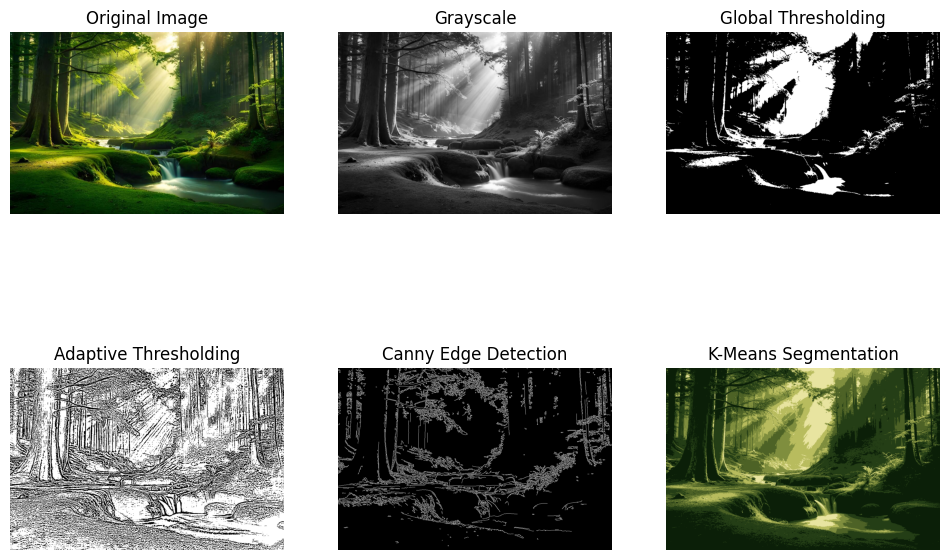

In [36]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(global_thresh, cmap='gray')
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(adaptive_thresh, cmap='gray')
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(segmented_image)
plt.title("K-Means Segmentation")
plt.axis("off")

plt.show()